In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score , mean_absolute_error
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson



In [63]:
df = pd.read_excel("B.25 US Motor Vehicle Traffic Fatalities.xlsx" , header = 3) #hence the dataset starting from row 3 we choose header 3

In [64]:
df #checking the dataset

,Year,Fatalities,Resident Population (Thousands),Licensed Drivers (Thousands),Registered Motor Vehicles (Thousands),Vehicle Miles Traveled (Billions),Annual Unemployment Rate (%)
0,1966,50894,196560,100998,95703,926,3.8
1,1967,50724,198712,103172,98859,964,3.8
2,1968,52725,200706,105410,102987,1016,3.6
3,1969,53543,202677,108306,107412,1062,3.5
4,1970,52627,205052,111543,111242,1110,4.9
5,1971,52542,207661,114426,116330,1179,5.9
6,1972,54589,209896,118414,122557,1260,5.6
7,1973,54052,211909,121546,130025,1313,4.9
8,1974,45196,213854,125427,134900,1281,5.6
9,1975,44525,215973,129791,126153,1328,8.5


([<matplotlib.axis.XTick at 0x13f74de50>,
 [Text(1966, 0, '1966'),
  Text(1968, 0, '1968'),
  Text(1970, 0, '1970'),
  Text(1972, 0, '1972'),
  Text(1974, 0, '1974'),
  Text(1976, 0, '1976'),
  Text(1978, 0, '1978'),
  Text(1980, 0, '1980'),
  Text(1982, 0, '1982'),
  Text(1984, 0, '1984'),
  Text(1986, 0, '1986'),
  Text(1988, 0, '1988'),
  Text(1990, 0, '1990'),
  Text(1992, 0, '1992'),
  Text(1994, 0, '1994'),
  Text(1996, 0, '1996'),
  Text(1998, 0, '1998'),
  Text(2000, 0, '2000'),
  Text(2002, 0, '2002'),
  Text(2004, 0, '2004'),
  Text(2006, 0, '2006'),
  Text(2008, 0, '2008'),
  Text(2010, 0, '2010'),
  Text(2012, 0, '2012')])

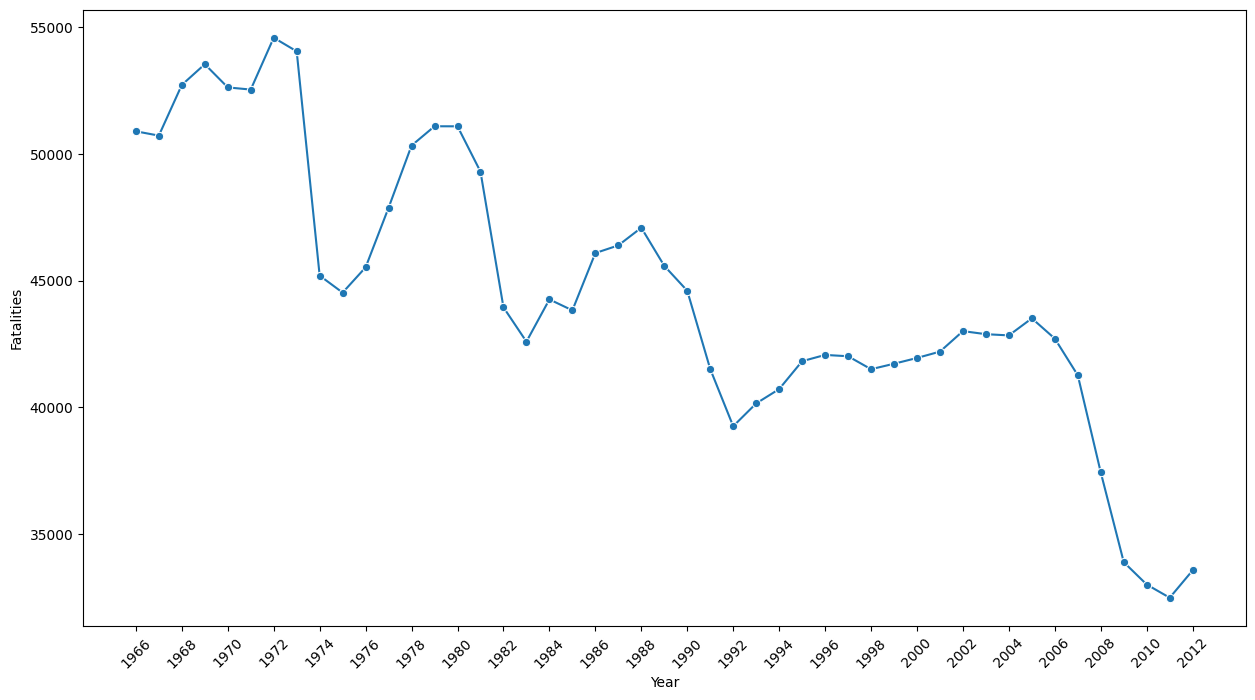

In [65]:
#a-) Plot the fatalities data. Comment on the graph.
plt.figure(figsize = (15,8))
sns.lineplot(data = df, x = 'Year',y  = 'Fatalities',marker = 'o')
plt.xticks(df['Year'][::2],rotation = 45)


<Axes: xlabel='Licensed Drivers (Thousands)', ylabel='Fatalities'>

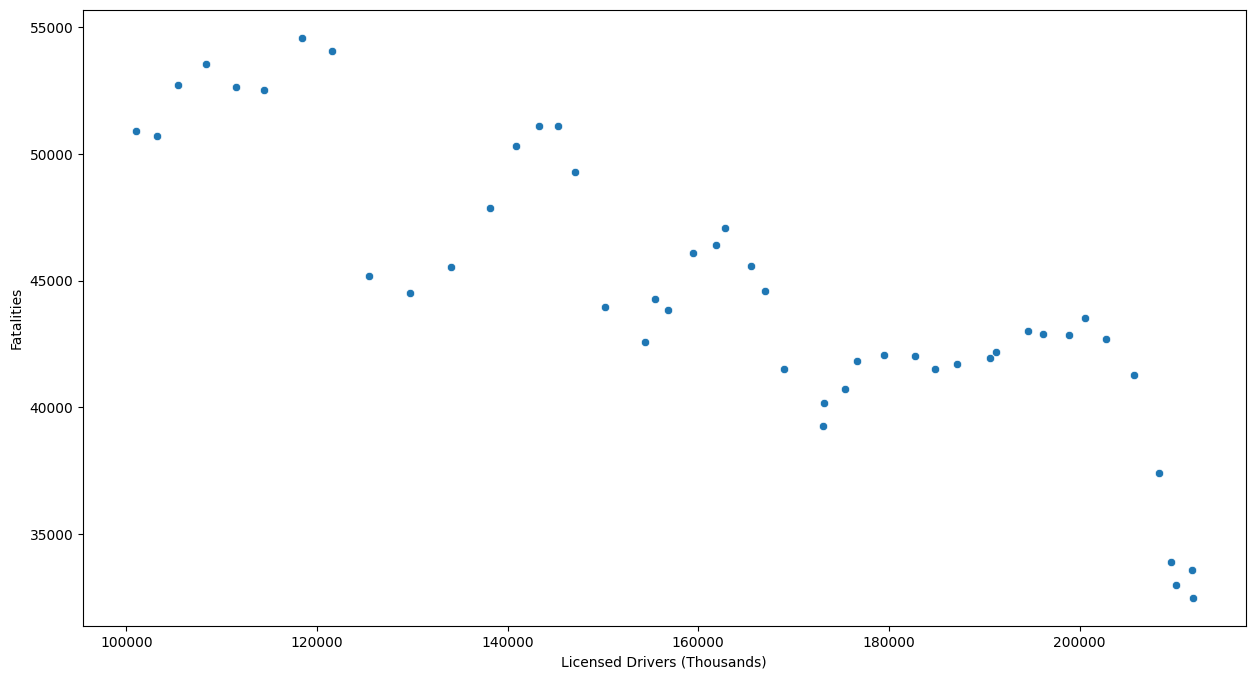

In [66]:
#b-)Construct a scatter plot of fatalities versus number of licensed drivers.
#Comment on the apparent relationship between these two factors.
plt.figure(figsize =(15,8))
sns.scatterplot(data = df , x = 'Licensed Drivers (Thousands)',y = 'Fatalities')



In [67]:
#c-)Fit a simple linear regression model to the fatalities data, using the number of
#licensed drivers as the predictor variable. Discuss the summary statistics from this
#model.
X = df[["Licensed Drivers (Thousands)"]]
Y = df[["Fatalities"]]
model = LinearRegression()
model.fit(X,Y)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [97]:
Y_predict = model.predict(X)


r2_score = model.score(X,Y)
mse = mean_squared_error(Y,Y_predict)
mae = mean_absolute_error(Y,Y_predict)
print(f"r2 score :{r2_score:.4f}\n"
f"mean squared error :{mse:.4f}\n"
f"mean absolute error:{mae:4f}")

r2 score :0.7452
mean squared error :7736578.8920
mean absolute error:2380.253080


In [78]:
# d-) Analyze the residuals from the model in part c. Discuss the adequacy of the fitted model.
Y_pred = model.predict(X)
residuals = Y - Y_pred

<function matplotlib.pyplot.show(close=None, block=None)>

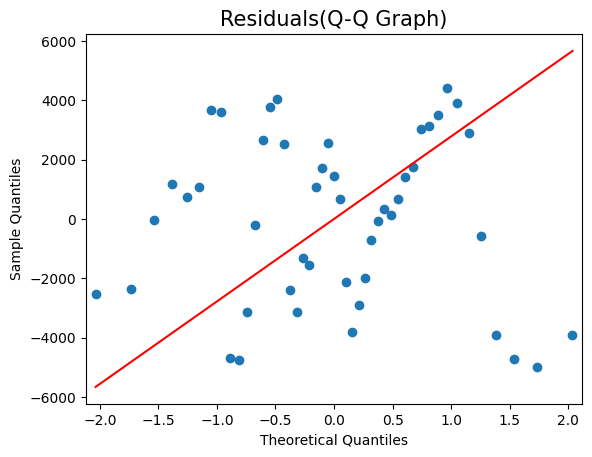

In [80]:
sm.qqplot(residuals , line = 's')
plt.title('Residuals(Q-Q Graph)', fontsize = 15)
plt.show

In [83]:
durbin_watson_test_statistic = durbin_watson(residuals)
print(durbin_watson_test_statistic)

[0.51811059]
